In [1]:
import kglab
import pickle
import rdflib 
import re
import torch
import json
import gc

import networkx as nx
import pandas as pd
import numpy as np
import torch.nn.functional as F
import matplotlib.pyplot as plt

from tqdm.notebook import tqdm
from collections import Counter, defaultdict
from sentence_transformers import SentenceTransformer, util
from sklearn.metrics.pairwise import cosine_similarity

tqdm.pandas()

In [2]:
triples = pd.read_excel("../outputs/clean_outputs/triples_clean.xlsx").drop("Unnamed: 0", axis=1)
triples.head()

,Unnamed: 0.1,id,company,job title,text,triples_qwen_structured,triples_qwen_semi-structured,triples_qwen_unstructured,triples_gemma_structured,triples_gemma_semi-structured,triples_gemma_unstructured,triples_llama_structured,triples_llama_semi-structured,triples_llama_unstructured
0,0,1527392,Jobindex,"IT-administrator – få indflydelse på et setup,...",Vil du ind i en virksomhed i rivende udvikling...,"[('IT-administrator', 'REQUIRES_SKILL', 'setup...","[('IT-administrator', 'REQUIRES_SKILL', 'netwo...","[('IT-administrator', 'requires', 'technical_s...","[('IT-administrator', 'INVOLVES_TASK', 'Mainta...","[('IT-administrator', 'REQUIRES_SKILL', 'Syste...",[('IT-administrator – få indflydelse på et set...,"[('IT-administrator', 'REQUIRES_SKILL', 'setup...","[('REQUIRES_SKILL', 'IT-administrator', 'Docke...","[('IT-administrator', 'har', 'få indflydelse p..."
1,1,1527395,Jobindex,"IT-administrator – få indflydelse på et setup,...","IT-administrator – få indflydelse på et setup,...","[('IT-administrator', 'REQUIRES_SKILL', 'setup...","[('IT-administrator', 'REQUIRES_SKILL', 'netwo...","[('IT-administrator', 'requires', 'technical_s...","[('IT-administrator', 'REQUIRES_SKILL', 'IT Ad...","[('IT-administrator', 'REQUIRES_SKILL', 'Syste...",[('IT-administrator – få indflydelse på et set...,"[('IT-administrator', 'REQUIRES_SKILL', 'Docke...",[('IT-administrator – få indflydelse på et set...,"[('IT-administrator', 'har', 'få indflydelse p..."
2,2,1527397,Aqua d'Or Mineral Water A/S,SQE Manager,For jobsøgere For arbejdsgivere Aqua d'Or Mi...,"[('SQE Manager', 'REQUIRES_SKILL', 'Root Cause...","[('SQE Manager', 'REQUIRES_SKILL', 'Quality Ma...","[('SQE Manager', 'requires', 'quality assuranc...","[('SQE Manager', 'REQUIRES_SKILL', 'Quality As...","[('SQE Manager', 'REQUIRES_SKILL', 'Quality As...","[('SQE Manager', 'title', 'SQE Manager'), ('SQ...","[('SQE Manager', 'REQUIRES_QUALITY', 'detail-o...","[('SQE Manager', 'REQUIRES_SKILL', 'DevOps Eng...","[('SQE Manager', 'requires', 'English language..."
3,3,1527417,Klimabrands,Kundeservice / teknisk support,For jobsøgere For arbejdsgivere mailto:job@k...,"[('Kundeservice / teknisk support', 'REQUIRES_...","[('Kundeservice / teknisk support', 'REQUIRES_...","[('Kundeservice / teknisk support', 'requires'...","[('Kundeservice / teknisk support', 'REQUIRES_...","[('Kundeservice / teknisk support', 'REQUIRES_...","[('Kundeservice / teknisk support', 'title', '...","[('Kundeservice', 'REQUIRES_QUALITY', 'detail-...","[('Kundeservice', 'REQUIRES_SKILL', 'Teknisk s...","[('Kundeservice', 'har', 'en teknisk support s..."
4,4,1527440,Scan Studio ApS,Retail designer med teknikken på plads,For jobsøgere For arbejdsgivere Scan Studio ...,"[('Retail Designer', 'REQUIRES_SKILL', 'Techni...","[('Retail Designer', 'REQUIRES_SKILL', 'Design...","[('Retail Designer', 'requires', 'technical sk...","[('Retail designer', 'REQUIRES_SKILL', 'teknik...","[('Retail designer', 'REQUIRES_SKILL', 'teknik...","[('Retail designer med teknikken på plads', 'h...","[('Retail designer med teknikken på plads', 'R...","[('Dansk designer', 'SKILL', 'REQUIRES_QUALITY...",[('Retail designer requires technisk kompetenc...


In [3]:
def extract_triples(input_string):
    """
    Extracts only 3-element tuples, accepting single or double quotes.
    """
    
    processed_string = input_string.replace('*', '"')

    # Quoting Group (Q): This group (r'["\']') matches either a double quote OR a single quote.
    Q = r'["\']' 
        
    # Flexible Pattern (using f-string for clarity and Q definition):
    pattern = rf"""
        \(              # Match the literal opening parenthesis (
        ({Q}.*?{Q})     # Group 1: Capture the first quoted string
        ,\s* # Match comma, optional whitespace
        ({Q}.*?{Q})     # Group 2: Capture the second quoted string
        ,\s* # Match comma, optional whitespace
        ({Q}.*?{Q})     # Group 3: Capture the third quoted string
        \)              # Match the literal closing parenthesis )
    """
    
    # Use re.findall with re.VERBOSE for multiline pattern and re.DOTALL to match across newlines
    matches = re.findall(pattern, processed_string, re.VERBOSE | re.DOTALL)
    
    extracted_data = []
    for str1_quoted, str2_quoted, str3_quoted in matches:
        # Remove the surrounding quotes from each captured string
        # using the replace method, which handles both ' and "
        str1 = str1_quoted.strip().replace('"', '').replace("'", '')
        str2 = str2_quoted.strip().replace('"', '').replace("'", '')
        str3 = str3_quoted.strip().replace('"', '').replace("'", '')
        extracted_data.append((str1, str2, str3))
        
    return extracted_data

for model in ["qwen", "gemma", "llama"]:
    for prompt in ["structured", "semi-structured", "unstructured"]:
        triples[f"triples_{model}_{prompt}"] = triples[f"triples_{model}_{prompt}"].apply(extract_triples)

In [4]:
triples.head(50)

,Unnamed: 0.1,id,company,job title,text,triples_qwen_structured,triples_qwen_semi-structured,triples_qwen_unstructured,triples_gemma_structured,triples_gemma_semi-structured,triples_gemma_unstructured,triples_llama_structured,triples_llama_semi-structured,triples_llama_unstructured
0,0,1527392,Jobindex,"IT-administrator – få indflydelse på et setup,...",Vil du ind i en virksomhed i rivende udvikling...,"[(IT-administrator, REQUIRES_SKILL, setup mana...","[(IT-administrator, REQUIRES_SKILL, network ma...","[(IT-administrator, requires, technical_setup_...","[(IT-administrator, INVOLVES_TASK, Maintaining...","[(IT-administrator, REQUIRES_SKILL, System Adm...",[(IT-administrator – få indflydelse på et setu...,"[(IT-administrator, REQUIRES_SKILL, setup), (I...","[(REQUIRES_SKILL, IT-administrator, Docker), (...","[(IT-administrator, har, få indflydelse på et ..."
1,1,1527395,Jobindex,"IT-administrator – få indflydelse på et setup,...","IT-administrator – få indflydelse på et setup,...","[(IT-administrator, REQUIRES_SKILL, setup mana...","[(IT-administrator, REQUIRES_SKILL, network ma...","[(IT-administrator, requires, technical_setup_...","[(IT-administrator, REQUIRES_SKILL, IT Adminis...","[(IT-administrator, REQUIRES_SKILL, System adm...",[(IT-administrator – få indflydelse på et setu...,"[(IT-administrator, REQUIRES_SKILL, Docker), (...",[(IT-administrator – få indflydelse på et setu...,"[(IT-administrator, har, få indflydelse på et ..."
2,2,1527397,Aqua d'Or Mineral Water A/S,SQE Manager,For jobsøgere For arbejdsgivere Aqua d'Or Mi...,"[(SQE Manager, REQUIRES_SKILL, Root Cause Anal...","[(SQE Manager, REQUIRES_SKILL, Quality Managem...","[(SQE Manager, requires, quality assurance), (...","[(SQE Manager, REQUIRES_SKILL, Quality Assuran...","[(SQE Manager, REQUIRES_SKILL, Quality Assuran...","[(SQE Manager, title, SQE Manager), (SQE Manag...","[(SQE Manager, REQUIRES_QUALITY, detail-orient...","[(SQE Manager, REQUIRES_SKILL, DevOps Engineer...","[(SQE Manager, requires, English language prof..."
3,3,1527417,Klimabrands,Kundeservice / teknisk support,For jobsøgere For arbejdsgivere mailto:job@k...,"[(Kundeservice / teknisk support, REQUIRES_SKI...","[(Kundeservice / teknisk support, REQUIRES_SKI...","[(Kundeservice / teknisk support, requires, cu...","[(Kundeservice / teknisk support, REQUIRES_SKI...","[(Kundeservice / teknisk support, REQUIRES_SKI...","[(Kundeservice / teknisk support, title, Kunde...","[(Kundeservice, REQUIRES_QUALITY, detail-orien...","[(Kundeservice, REQUIRES_SKILL, Teknisk suppor...","[(Kundeservice, har, en teknisk support specia..."
4,4,1527440,Scan Studio ApS,Retail designer med teknikken på plads,For jobsøgere For arbejdsgivere Scan Studio ...,"[(Retail Designer, REQUIRES_SKILL, Technical D...","[(Retail Designer, REQUIRES_SKILL, Design), (R...","[(Retail Designer, requires, technical skills)...","[(Retail designer, REQUIRES_SKILL, teknikken),...","[(Retail designer, REQUIRES_SKILL, teknikken),...","[(Retail designer med teknikken på plads, has_...","[(Retail designer med teknikken på plads, REQU...","[(Dansk designer, SKILL, REQUIRES_QUALITY), (D...",[(Retail designer requires technisk kompetence...
5,5,1527442,Jobindex,Supporter til Caseware – bliv kundernes superh...,For jobsøgere For arbejdsgivere CaseWare Od...,"[(Supporter til Caseware, REQUIRES_SKILL, Cust...","[(Supporter til Caseware, REQUIRES_SKILL, cust...",[(Supporter til Caseware – bliv kundernes supe...,"[(Supporter til Caseware, REQUIRES_QUALITY, cu...","[(Supporter til Caseware, REQUIRES_SKILL, Kund...",[(Supporter til Caseware – bliv kundernes supe...,[(Supporter til Caseware – bliv kundernes supe...,"[(REQUIRES_SKILL, Docker, Senior Dev), (REQUIR...",[(Supporter til Caseware – bliv kundernes supe...
6,6,1527454,Lebara ApS,Glade medarbejdere til et stærkt kundeserviceteam,"Brænder du for kundekontakt, og er du skarp på...",[(Glade medarbejdere til et stærkt kundeservic...,[(Glade medarbejdere til et stærkt kundeservic...,[(Glade medarbej

In [5]:
def clean_entity(entity):
    return entity.replace("_", " ").lower()

def extract_entities(triples):
    return list(np.array([[clean_entity(i[0]), clean_entity(i[2])] for i in triples]).flatten().tolist())

all_entities = []

for model in ["qwen", "gemma", "llama"]:
    for prompt in ["structured", "semi-structured", "unstructured"]:
        all_entities.extend(triples[f"triples_{model}_{prompt}"].progress_apply(extract_entities).values)

entity_list = list(set([
    entity
    for entities in all_entities
    for entity in entities
]))

  0%|          | 0/10584 [00:00<?, ?it/s]

  0%|          | 0/10584 [00:00<?, ?it/s]

  0%|          | 0/10584 [00:00<?, ?it/s]

  0%|          | 0/10584 [00:00<?, ?it/s]

  0%|          | 0/10584 [00:00<?, ?it/s]

  0%|          | 0/10584 [00:00<?, ?it/s]

  0%|          | 0/10584 [00:00<?, ?it/s]

  0%|          | 0/10584 [00:00<?, ?it/s]

  0%|          | 0/10584 [00:00<?, ?it/s]

In [6]:
len(entity_list)

523433

In [7]:
with open("../../dataset/final_dataset/anon_cvs.json", 'r', encoding="utf-8") as f:
    data = json.load(f)

In [8]:
cv_entities = []

for sample in data:
    for l in ["job_history", "jobtitles", "keywords"]:
        if type(sample[l]) == list:
            cv_entities.extend(sample[l])

cv_entities = set([clean_entity(i) for i in cv_entities if type(i) == str])  
entity_list.extend(list(cv_entities))

In [9]:
device = ("cuda:0" if torch.cuda.is_available() else "cpu")
print(device)
emb_model = SentenceTransformer('jjzha/dajobbert-base-uncased').to(device)

entity_embs = {}

for entity in tqdm(entity_list):
    if type(entity) == float and np.isnan(entity):
        continue
    
    entity_embs[entity] = emb_model.encode(entity.replace("_", " "), convert_to_tensor=True)

entity_list = list(entity_embs.keys())

del emb_model
torch.cuda.empty_cache() 
torch.cuda.ipc_collect()
gc.collect()

cuda:0


No sentence-transformers model found with name jjzha/dajobbert-base-uncased. Creating a new one with mean pooling.
Some weights of BertModel were not initialized from the model checkpoint at jjzha/dajobbert-base-uncased and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


  0%|          | 0/666499 [00:00<?, ?it/s]

3665

In [16]:
class TensorEncoder(json.JSONEncoder):
    def default(self, obj):
        if torch.is_tensor(obj):
            return obj.tolist()
        return super().default(obj)

In [19]:
with open("entity_embeddings.json", "w") as fp:
    json.dump(entity_embs, fp, cls=TensorEncoder)

In [10]:
ordered_keys = list(entity_embs.keys())
entity_list = ordered_keys
ordered_embeddings = [entity_embs[key] for key in ordered_keys]

embeddings = torch.stack(ordered_embeddings).to("cpu")
embeddings_array = F.normalize(embeddings, p=2, dim=1).to(torch.float32)
similarity_matrix = cosine_similarity(embeddings_array.numpy(), embeddings_array.numpy())

MemoryError: Unable to allocate 1.54 TiB for an array with shape (650776, 650776) and data type float32

In [11]:
# Assuming 'embeddings_array' is your NumPy array of normalized embeddings (N x D)
import faiss
import numpy as np

# N = 145248, D = embedding dimension (e.g., 768)
N = embeddings_array.shape[0]
D = embeddings_array.shape[1]

# Build the FAISS Index (HNSW for speed and accuracy)
index = faiss.IndexFlatIP(D)   # D=dimension, 32=number of connections per layer
index.add(embeddings_array)

In [12]:
threshold = 0.95

K = 50 # Find the 25 closest neighbors for every entity
high_quality_pairs = []

for ent1_idx, emb in tqdm(enumerate(embeddings_array), total=len(embeddings_array)):
    # Search faiss, K+1 to account for self
    similarities, indices = index.search(emb.reshape(1, -1), K + 1)

    for i, ent2_idx in enumerate(indices[0]):
        # Ignore self
        if ent1_idx == ent2_idx:
            continue

        similarity = similarities[0][i]
      
        if similarity >= threshold:            
            high_quality_pairs.append((entity_list[ent1_idx], entity_list[ent2_idx], similarity))

  0%|          | 0/650776 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [11]:
high_quality_pairs[:5]

[('cross functional collaboration',
  'cross-functional collaboration',
  np.float32(0.990424)),
 ('cross functional collaboration',
  'cross-functional collaborations',
  np.float32(0.9810531)),
 ('understanding of quality legislation',
  'understanding of quality and environmental legislation',
  np.float32(0.9540143)),
 ('performance based bonus',
  'performance-based bonus',
  np.float32(0.98016185)),
 ('performance based bonus', 'performance-based-bonus', np.float32(0.9581204))]

In [12]:
class ArrayUnionFind:
    def __init__(self, N):
        # N is the total number of entities (145248)
        self.parent = list(range(N))
        self.rank = [0] * N

    def find(self, i):
        """Finds the root iteratively (using integer index i)."""
        # Find the root iteratively
        root = i
        while self.parent[root] != root:
            root = self.parent[root]
        
        # Path Compression
        current = i
        while self.parent[current] != root:
            next_parent = self.parent[current]
            self.parent[current] = root
            current = next_parent
            
        return root

    def union(self, i, j):
        """Unites the sets containing index i and j."""
        root_i = self.find(i)
        root_j = self.find(j)

        if root_i != root_j:
            # Union by Rank
            if self.rank[root_i] < self.rank[root_j]:
                self.parent[root_i] = root_j
            elif self.rank[root_i] > self.rank[root_j]:
                self.parent[root_j] = root_i
            else:
                self.parent[root_j] = root_i
                self.rank[root_i] += 1
            return True
        return False

def coalesce_by_dsu(scored_data, unclustered_strings, threshold=0.80):
    # Create Index Mappings (String <-> Integer Index)
    string_to_index = {s: i for i, s in enumerate(unclustered_strings)}
    N = len(unclustered_strings)
    
    # Initialize the Array-Based Union-Find
    dsu = ArrayUnionFind(N)

    # Process all similarity scores using indices (Fast)
    print("Processing scores with array DSU...")
    
    # Note: We must iterate over scored_data, not unclustered_strings
    for s1, s2, score in tqdm(scored_data, desc="Processing Scores"):
        if score >= threshold:
            try:
                idx1 = string_to_index[s1]
                idx2 = string_to_index[s2]
                dsu.union(idx1, idx2)
            except KeyError:
                # Handle cases where s1 or s2 might not be in unclustered_strings
                pass 
                
    # Extract the final clusters by grouping elements by their root (Fast)
    print("Extracting clusters...")
    
    # Group the indices by their root
    index_clusters_map = defaultdict(list)
    
    # The progress bar iterates over the N indices (0 to 145247)
    for i in tqdm(range(N), desc="Extracting Clusters"):
        root_index = dsu.find(i)
        index_clusters_map[root_index].append(i)
        
    # Convert Index Clusters back to String Clusters
    final_string_clusters = []
    
    # The index_to_string map is simply the list of unclustered_strings
    index_to_string = list(unclustered_strings)
    
    for index_list in index_clusters_map.values():
        string_cluster = [index_to_string[idx] for idx in index_list]
        final_string_clusters.append(string_cluster)
        
    return final_string_clusters

In [13]:
similarity_clusters = coalesce_by_dsu(
    scored_data=high_quality_pairs,
    unclustered_strings=entity_list,
    threshold=threshold # Use the same threshold for the final merge
)

Processing scores with array DSU...


Processing Scores:   0%|          | 0/166927 [00:00<?, ?it/s]

Extracting clusters...


Extracting Clusters:   0%|          | 0/143768 [00:00<?, ?it/s]

In [14]:
cluster_lengths = [len(i) for i in similarity_clusters]

np.mean(cluster_lengths), max(cluster_lengths), len(cluster_lengths)

(np.float64(1.2326739889051797), 6738, 116631)

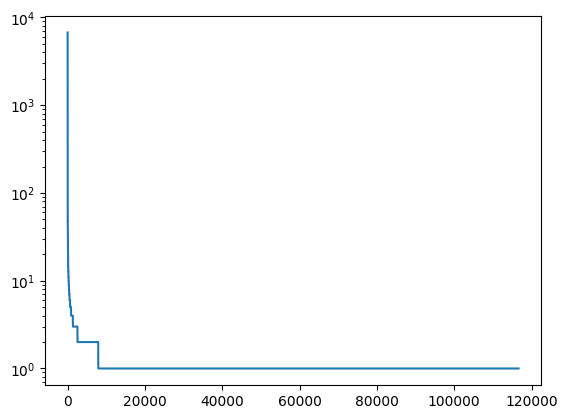

In [15]:
plt.plot(sorted(cluster_lengths, reverse=True))
plt.yscale('log')

In [16]:
def apply_cluster_size_cap(similarity_clusters, max_size=100):
    """
    Separates giant, likely nonsensical clusters (formed by single linkage) 
    into individual, ungrouped entities.
    """
    final_clusters = []
    
    for cluster in similarity_clusters:
        if len(cluster) <= max_size:
            # Keep small, high-quality clusters as they are
            final_clusters.append(cluster)
        else:
            # Break large clusters into singleton clusters (no grouping)
            print(f"Warning: Breaking cluster of size {len(cluster)} > {max_size}")
            for entity in cluster:
                final_clusters.append([entity]) # Append as a list of 1
                
    return final_clusters

final_clusters = apply_cluster_size_cap(similarity_clusters, max_size=100)

In [17]:
canonical_map = {}

for cluster in tqdm(final_clusters):
    # Pick the shortest string, as it's often the most concise.

    if any([type(i) == float for i in cluster]):
        continue
        
    canonical = min(cluster, key=len)

    for original_string in cluster:
        canonical_map[original_string] = canonical.replace(" ", "_")

  0%|          | 0/126098 [00:00<?, ?it/s]

In [18]:
def map_list_of_triples_to_canonical(list_of_triples, canonical_map):
    """
    Iterates over a list of triples and updates the first (subject) 
    and third (object) elements of each triple using the canonical map.

    :param list_of_triples: A list where each item is a triple (a, b, c).
    :param canonical_map: The dictionary mapping original strings to canonical strings.
    :return: A new list of triples with canonicalized entities.
    """
    canonicalized_list = []

    for triple in eval(list_of_triples):
        # Assuming the triple is iterable (e.g., a list or tuple)
        if len(triple) != 3:
            # Handle malformed triples if necessary, or skip them
            canonicalized_list.append(triple)
            continue
            
        a, b, c = triple

        # Check and replace 'a' (subject)
        # .get(key, default) returns the original 'a' if not found
        new_a = canonical_map.get(a, a) 

        # Check and replace 'c' (object)
        new_c = canonical_map.get(c, c) 

        # Append the new, canonicalized triple
        canonicalized_list.append((new_a, b, new_c))
        
    return canonicalized_list

In [19]:
triples['triples'] = triples['triples'].apply(
    lambda list_of_triples: map_list_of_triples_to_canonical(list_of_triples, canonical_map)
)

In [20]:
triples.to_excel("../outputs/raw_outputs/generated_triples_coalesced.xlsx")

In [21]:
def map_json_entities_to_canonical(json_list, canonical_map, keys_to_map=None):
    """
    Updates entities within lists under specified keys in a list of dictionaries (JSON format)
    to their canonical forms.

    :param json_list: The list of dictionaries (your JSON data).
    :param canonical_map: The dictionary mapping original strings to canonical strings.
    :param keys_to_map: The keys whose values (lists of entities) should be mapped.
                        Defaults to ['job_history', 'jobtitles', 'keywords'].
    :return: A new list of dictionaries with canonicalized entity lists.
    """
    if keys_to_map is None:
        keys_to_map = ['job_history', 'jobtitles', 'keywords']
        
    canonicalized_json = []

    for entity_dict in json_list:
        new_dict = {}
        
        # Iterate over all keys in the dictionary
        for key, value in entity_dict.items():
            
            # Check if the key is one we need to map AND if the value is a list
            if key in keys_to_map and isinstance(value, list):
                
                canonicalized_list = []
                # Iterate through every entity in the list value
                for entity in value:
                    # Replace the entity with its canonical form if found in the map
                    # Otherwise, keep the original entity string
                    canonical_entity = canonical_map.get(entity, entity)
                    canonicalized_list.append(canonical_entity)
                
                new_dict[key] = list(set(canonicalized_list))
            
            # If the key is not one to map, or the value is not a list, copy it as is
            else:
                new_dict[key] = value
                
        canonicalized_json.append(new_dict)
        
    return canonicalized_json

In [22]:
coalesced_data = map_json_entities_to_canonical(data, canonical_map)

In [23]:
coalesced_data[:10]

[{'headline': 'Erfaren Senior IT SystemKonsulent',
  'educationlevel': 8.0,
  'jobexperiences': 35.0,
  'mgrexperiences': 2.0,
  'countryid': 4,
  'cvid': 'ebf358ed252344af8d1dd3f4c8516cbf',
  'job_history': ['It-drift og support',
   'IT-systemkonsulent',
   'Cloud Infrastructure Specialist',
   'IT-administrator',
   'High end drifts konsulent'],
  'educations': [{'type': 'education', 'name': 'EDB assistent'}],
  'languages': [{'code': 'en', 'level': 4},
   {'code': 'de', 'level': 2},
   {'code': 'da', 'level': 4}],
  'jobtitles': ['IT-konsulent',
   'Systemadministrator',
   'Systemansvarlig',
   'Senior Consultant',
   'IT-systemkonsulent',
   'IT-administrator',
   'IT-ansvarlig',
   'Senior konsulent',
   'Systemkonsulent'],
  'keywords': ['IT koordinator',
   'Microsoft Exchange',
   'Problemknuser',
   'Ledelse',
   'IT konsulent',
   'Windows',
   'nutanix',
   'Exchange server',
   'Serious and responsible',
   'SDM',
   'Azure',
   'Driftsteknik',
   'Driftsoptimering']},
 {

In [24]:
with open("anon_cvs_coalesced.json", 'w') as json_file:
        # json.dump() writes the dictionary to the file object
        json.dump(coalesced_data, json_file, indent=4)